In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [36]:
class BatsmanState(TypedDict):
    balls:int
    runs:int
    fours:int
    sixes:int
    
    sr:float
    bpb:float
    boundary_percent:float
    


In [37]:
def calculate_sr(state:BatsmanState):
    sr = (state['runs']/state['balls'])*100
    return {'sr':sr}

In [38]:
def calculate_bpb(state:BatsmanState):
    bpb = (state['balls']/(state['fours']+state['sixes']))
    return {'bpb':bpb}

In [39]:
def calculate_bper(state:BatsmanState):
    boundary_percent = ((state['fours']*4+state['sixes']*6)/state['runs'])*100
    return {'boundary_percent':boundary_percent}

In [40]:
graph = StateGraph(BatsmanState)
graph.add_node('calculate_sr',calculate_sr);
graph.add_node('calculate_bpb',calculate_bpb);
graph.add_node('calculate_bper',calculate_bper);

graph.add_edge(START,'calculate_sr');
graph.add_edge(START,'calculate_bpb');
graph.add_edge(START,'calculate_bper');

graph.add_edge('calculate_sr',END);
graph.add_edge('calculate_bpb',END);
graph.add_edge('calculate_bper',END);



In [41]:
workflow = graph.compile()

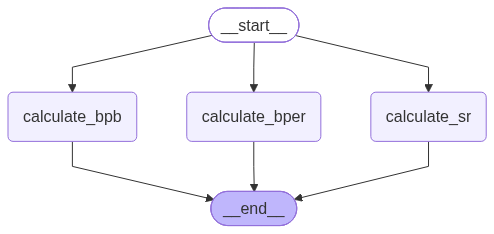

In [42]:
workflow

In [43]:
initial_state = {
    "runs":100,
    "balls":50,
    "fours":5,
    "sixes":5,
}

workflow.invoke(initial_state)

{'balls': 50,
 'runs': 100,
 'fours': 5,
 'sixes': 5,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 50.0}